In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
df.shape

(1000, 8)

In [6]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df['math score'].describe()

,math score
count,1000.00000
mean,66.08900
std,15.16308
min,0.00000
25%,57.00000
50%,66.00000
75%,77.00000
max,100.00000


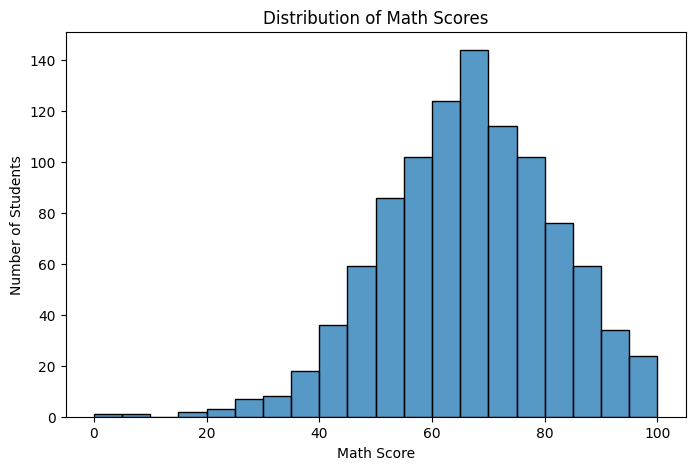

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['math score'], bins=20)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")

plt.show()

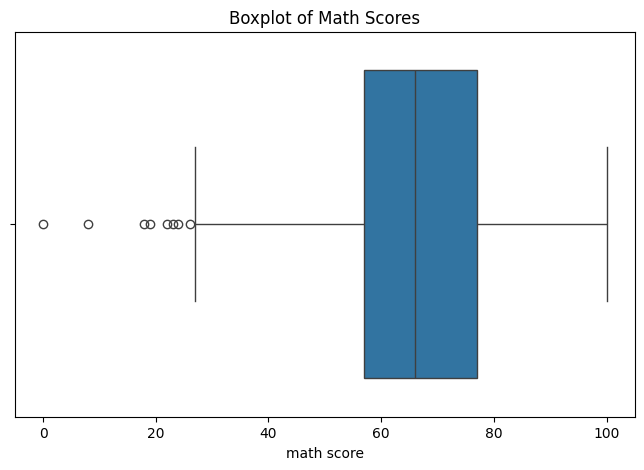

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['math score'])

plt.title("Boxplot of Math Scores")

plt.show()

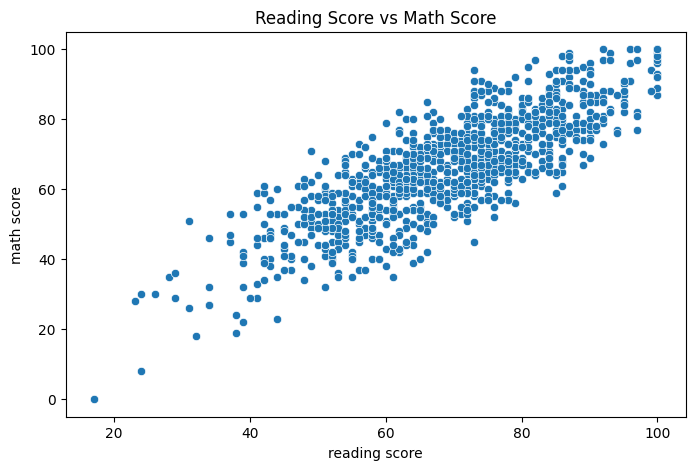

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['reading score'],
    y=df['math score']
)

plt.title("Reading Score vs Math Score")

plt.show()

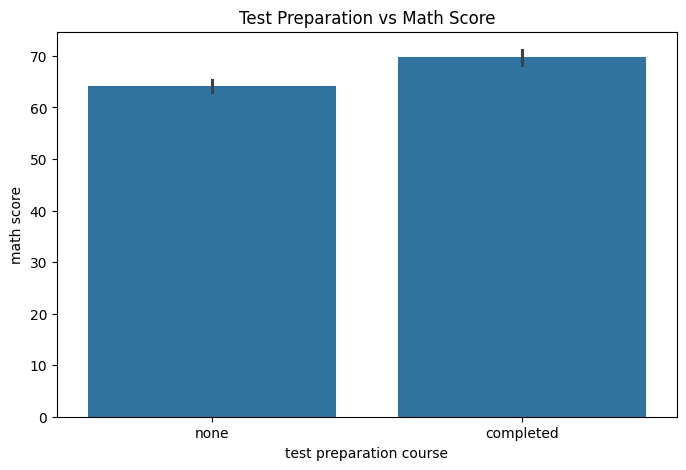

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='test preparation course',
    y='math score',
    data=df
)

plt.title("Test Preparation vs Math Score")

plt.show()

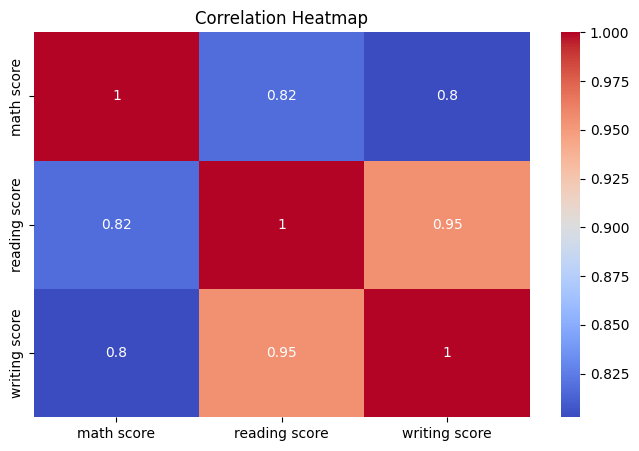

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
X = df.drop('math score', axis=1)

y = df['math score']

X → inputs
y → target

In [16]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [17]:
y.head()

,math score
0,72
1,69
2,90
3,47
4,76


In [18]:
X = pd.get_dummies(X, drop_first=True)

In [19]:
X.head()

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [20]:
X.shape

(1000, 14)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
X_train.shape

(800, 14)

In [24]:
X_test.shape

(200, 14)

In [26]:
y_train.shape

(800,)

In [27]:
y_test.shape

(200,)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
y_pred[:5]

array([76.3879697 , 58.88597004, 76.99026483, 76.85180448, 87.62737816])

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [34]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4.214763142474851


In [35]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 29.095169866715487


In [36]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5.393993869732843


In [37]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8804332983749565


In [38]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
521,91,76.387970
737,53,58.885970
740,80,76.990265
660,74,76.851804
411,84,87.627378
678,81,79.014024
626,69,64.654609
513,54,53.007919
859,87,74.184710
136,51,49.213538


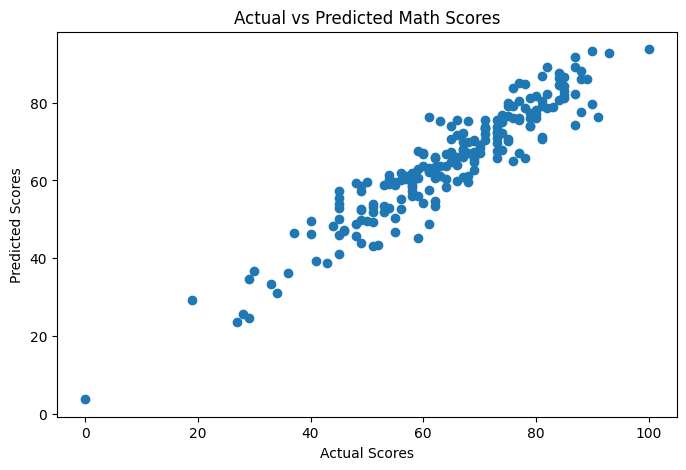

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Math Scores")

plt.show()

In [40]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [41]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [42]:
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R2:", dt_r2)

Decision Tree R2: 0.7107320505107291


In [43]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [44]:
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2:", rf_r2)

Random Forest R2: 0.8491990721184489


In [45]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,reading score,0.236023
1,writing score,0.724148
2,gender_male,13.064884
3,race/ethnicity_group B,0.359323
4,race/ethnicity_group C,-0.625617
5,race/ethnicity_group D,-0.613236
6,race/ethnicity_group E,4.892649
7,parental level of education_bachelor's degree,-0.716901
8,parental level of education_high school,0.929312
9,parental level of education_master's degree,-1.400489


In [46]:
coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
2,gender_male,13.064884
6,race/ethnicity_group E,4.892649
12,lunch_standard,3.510075
13,test preparation course_none,3.289642
10,parental level of education_some college,0.998856
8,parental level of education_high school,0.929312
11,parental level of education_some high school,0.756470
1,writing score,0.724148
3,race/ethnicity_group B,0.359323
0,reading score,0.236023


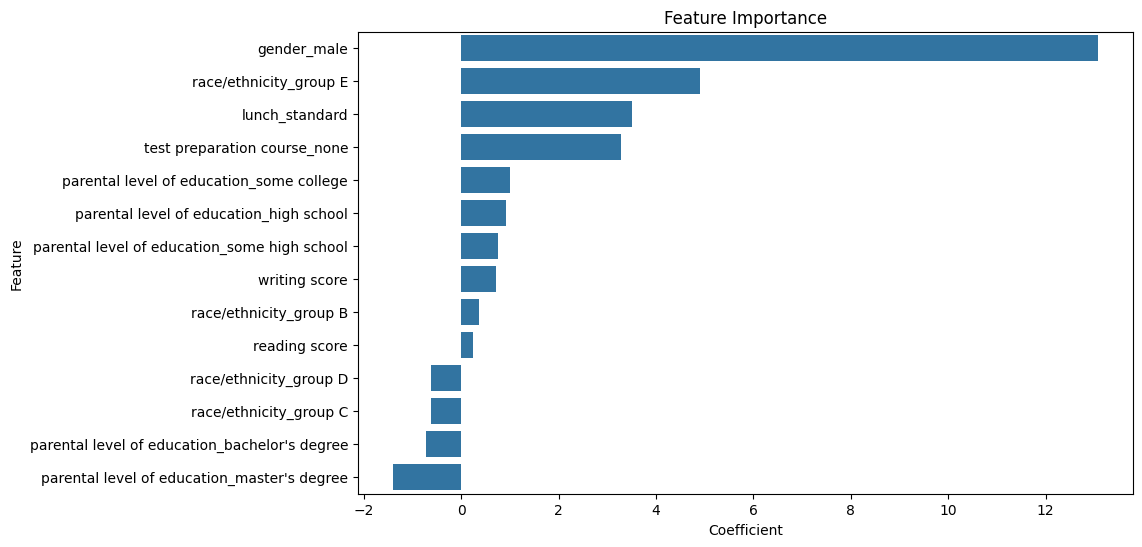

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients.sort_values(
        by='Coefficient',
        ascending=False
    )
)

plt.title("Feature Importance")

plt.show()